In [1]:
import os
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Ruta base del proyecto
PROJECT_DIR = "/beegfs/home/iruizdealda/HCC_singlecell_project"

# Rutas principales para no perderme
GENES_DIR = os.path.join(PROJECT_DIR, "170_genes")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")

# Carpeta específica para este dataset
FIGURES_DATASET_DIR = os.path.join(FIGURES_DIR, "GSE149614")

# Crear carpeta si no existe
os.makedirs(FIGURES_DATASET_DIR, exist_ok=True)

# Configurar Scanpy para guardar figuras
sc.settings.figdir = FIGURES_DATASET_DIR

In [3]:
# Cargar dataset

adata = sc.read_h5ad(os.path.join(DATA_DIR, "adata_GSE149614_raw.h5ad"))
adata

AnnData object with n_obs × n_vars = 71914 × 25712
    obs: 'sample', 'res.3', 'site', 'patient', 'stage', 'virus', 'celltype'

In [4]:
# Cargar excell de genes

genes_df = pd.read_excel(os.path.join(GENES_DIR, "170genes_clasificados_reclasificado.xlsx"))
genes_df.head()

gene_col = genes_df.columns[0]
func_col = genes_df.columns[1]

print("Columna de genes:", gene_col)
print("Columna de función:", func_col)

Columna de genes: COL11A1
Columna de función: ECM / Fibrosis / Colágeno


In [5]:
# Sacar lista de gens de interés y cruzarla con el dataset

genes_interes = genes_df[gene_col].dropna().astype(str).tolist()

print("Genes totales:", len(genes_interes))

genes_presentes = [g for g in genes_interes if g in adata.var_names]

print("Genes totales:", len(genes_interes))
print("Genes presentes:", len(genes_presentes))

Genes totales: 170
Genes totales: 170
Genes presentes: 161


In [6]:
# Crear el objeto filtrado con los genes de interés 

adata_170 = adata[:, genes_presentes].copy()
adata_170

AnnData object with n_obs × n_vars = 71914 × 161
    obs: 'sample', 'res.3', 'site', 'patient', 'stage', 'virus', 'celltype'

# ANÁLISIS GLOBAL

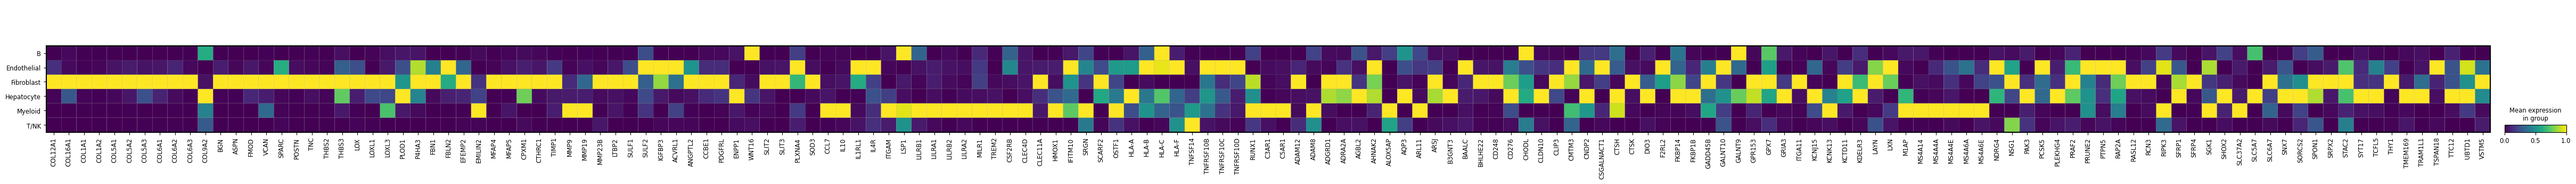

In [7]:
# MAXIPLOT 

sc.pl.matrixplot(
    adata_170,
    var_names=genes_presentes,
    groupby="celltype",
    standard_scale="var",
    save="_matrixplot_all_genes.png"
)

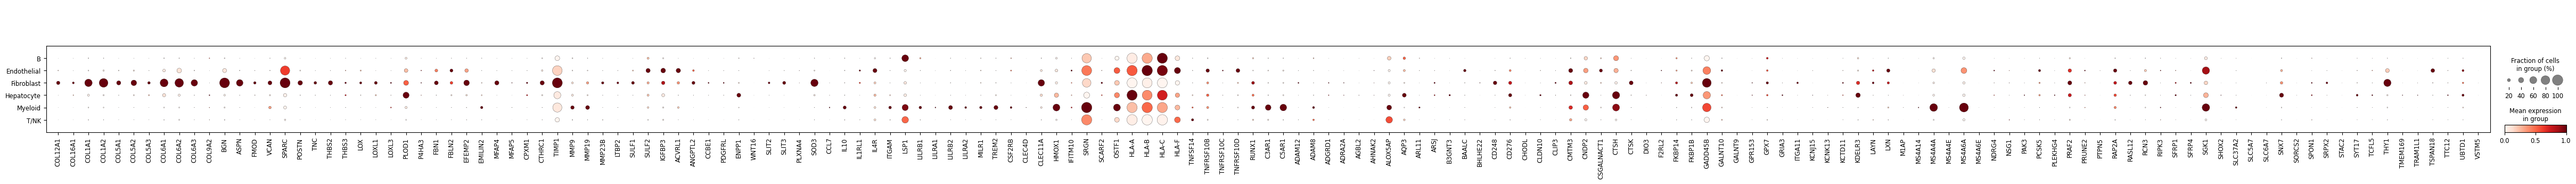

In [8]:
# DOTPLOT

sc.pl.dotplot(
    adata_170,
    var_names=genes_presentes,
    groupby="celltype",
    standard_scale="var",
    save="_dotplot_all_genes.png"
)

/tmp/ipykernel_1342646/1024311262.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = expr_df.groupby(level=0).mean()


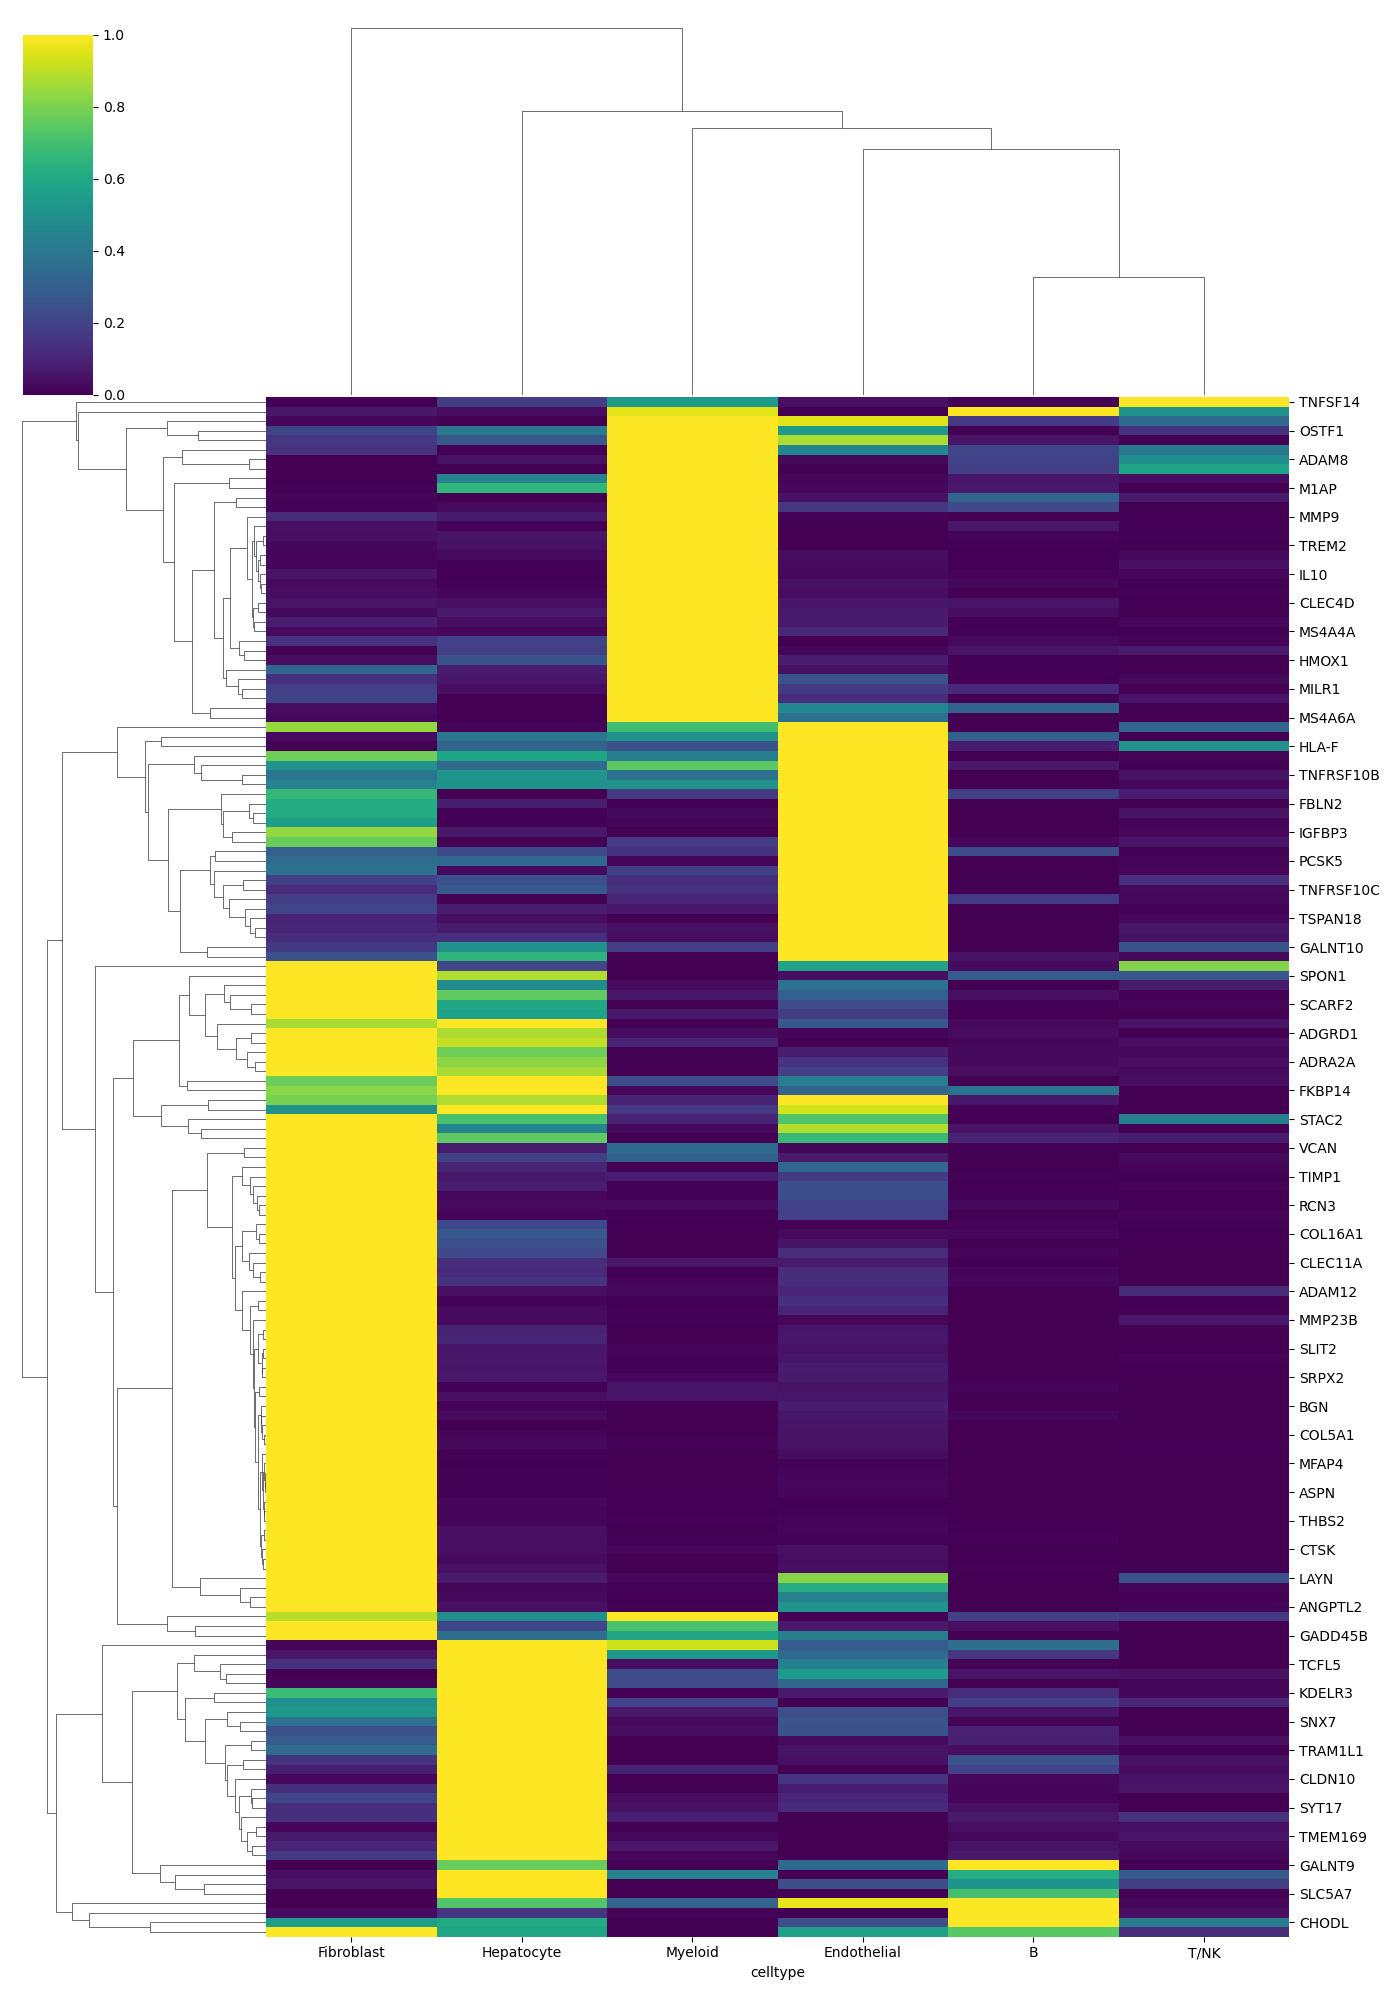

In [9]:
# Clustermap de expresión media por tipo celular

expr_df = pd.DataFrame(
    adata_170.X.toarray(),
    index=adata_170.obs["celltype"],
    columns=adata_170.var_names
)

mean_expr = expr_df.groupby(level=0).mean()
mean_expr_scaled = ((mean_expr - mean_expr.min()) / (mean_expr.max() - mean_expr.min())).fillna(0)

g = sns.clustermap(
    mean_expr_scaled.T,
    figsize=(14, 20),
    cmap="viridis",
    col_cluster=True,
    row_cluster=True,
)

g.savefig(
    os.path.join(FIGURES_DATASET_DIR, "clustermap_mean_expression_all_genes.png"),
    dpi=300
)

plt.show()
plt.close()

In [10]:
# Reagrupación más general de funciones

reagrupacion_general = {
    "ECM / Fibrosis / Colágeno": "ECM / Estroma / Remodelacion",
    "Proteolisis / remodelacion proteica": "ECM / Estroma / Remodelacion",
    "Adhesion / ECM / migracion": "ECM / Estroma / Remodelacion",
    "Glicosilacion / proteoglicanos / secrecion": "ECM / Estroma / Remodelacion",

    "Chemotaxis": "Inmunidad / Inflamacion / Chemotaxis",
    "Inmunidad / inflamacion": "Inmunidad / Inflamacion / Chemotaxis",
    "Complemento": "Inmunidad / Inflamacion / Chemotaxis",

    "Angiogénesis / Vascular": "Angiogenesis / Vascular / Hipoxia",
    "Hipoxia / estres / apoptosis": "Angiogenesis / Vascular / Hipoxia",

    "Señalizacion celular": "Señalizacion / Regulacion celular",
    "Desarrollo / regulacion": "Señalizacion / Regulacion celular",
    "Transporte / canales / trafico": "Señalizacion / Regulacion celular",

    "Neuronal / sinapsis": "Otros / poco clara",
    "Otros / funcion poco clara": "Otros / poco clara",
}

In [11]:
# Crear nueva columna

genes_df["grupo_general"] = genes_df[func_col].map(reagrupacion_general)
genes_df["grupo_general"].value_counts()

grupo_general
ECM / Estroma / Remodelacion            64
Inmunidad / Inflamacion / Chemotaxis    44
Señalizacion / Regulacion celular       31
Otros / poco clara                      16
Angiogenesis / Vascular / Hipoxia       15
Name: count, dtype: int64

# ECM

Grupo general: ECM / Estroma / Remodelacion
Número total de genes en el grupo: 64
Primeros genes del grupo: ['COL12A1', 'COL16A1', 'COL1A1', 'COL1A2', 'COL5A1', 'COL5A2', 'COL5A3', 'COL6A1', 'COL6A2', 'COL6A3']
Número de genes presentes en el dataset: 61
Primeros genes presentes: ['COL12A1', 'COL16A1', 'COL1A1', 'COL1A2', 'COL5A1', 'COL5A2', 'COL5A3', 'COL6A1', 'COL6A2', 'COL6A3']


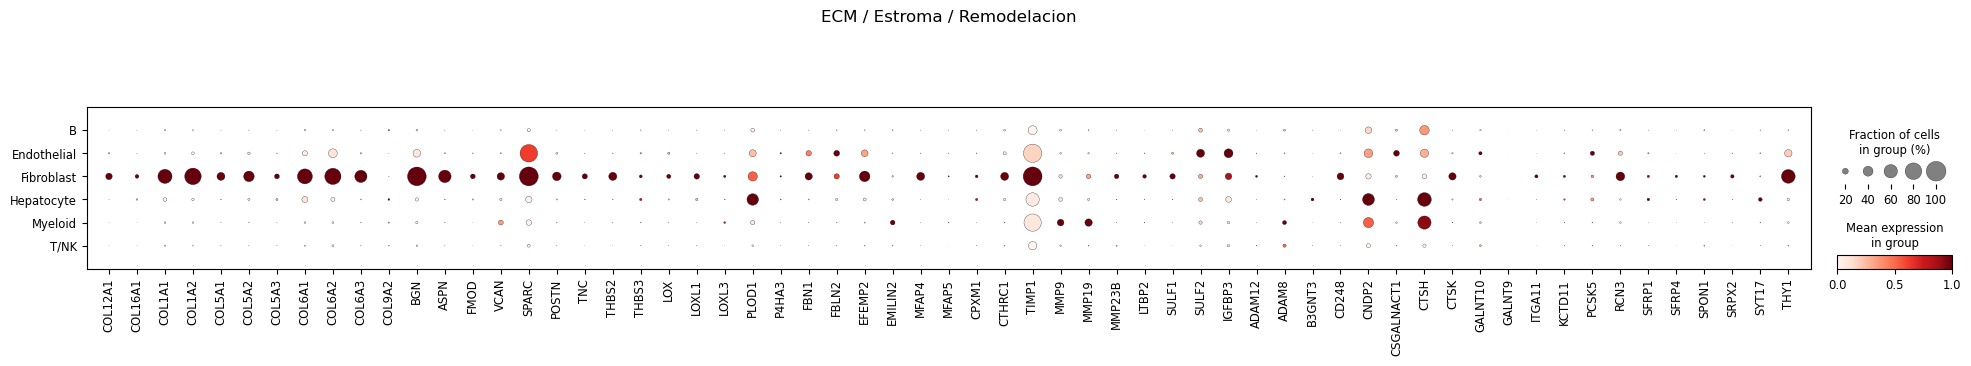

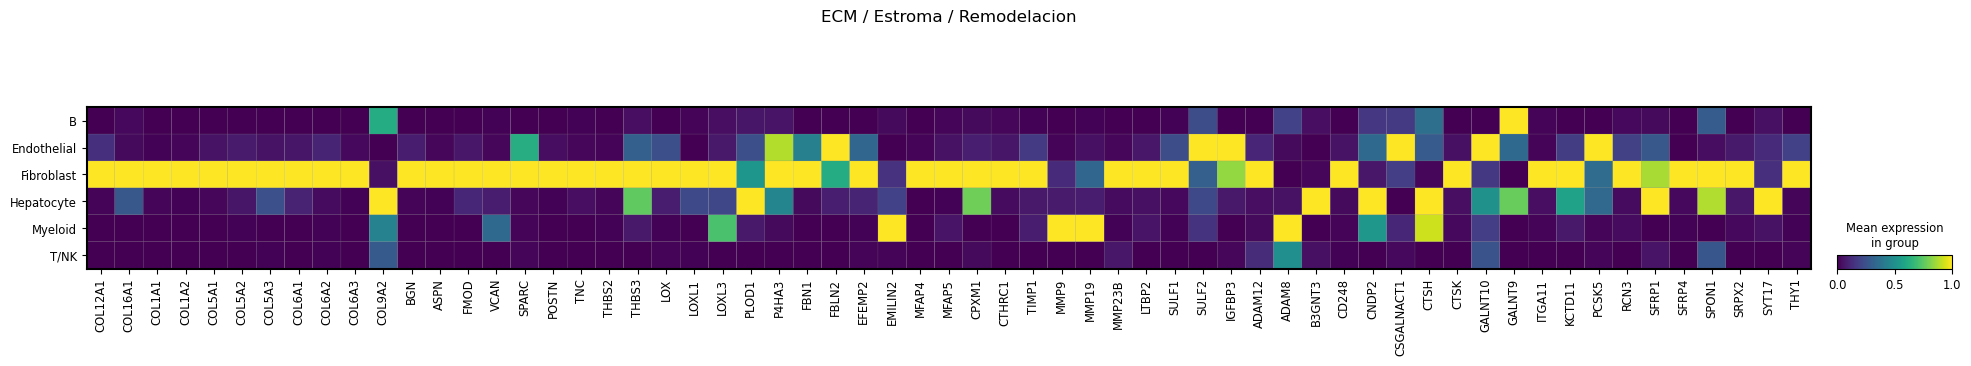

In [12]:
# ================================
# BLOQUE 2 · Analisis por grupo_general
# ================================

grupo = "ECM / Estroma / Remodelacion"
# otros ejemplos:
# grupo = "Inmunidad / Inflamacion / Chemotaxis"
# grupo = "Angiogenesis / Vascular / Hipoxia"
# grupo = "Señalizacion / Regulacion celular"
# grupo = "Otros / poco clara"

columna_grupo = "grupo_general"

# Sacar genes del grupo general
genes_grupo = (
    genes_df.loc[genes_df[columna_grupo] == grupo, gene_col]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"Grupo general: {grupo}")
print(f"Número total de genes en el grupo: {len(genes_grupo)}")
print("Primeros genes del grupo:", genes_grupo[:10])

# Comprobar cuáles están presentes en el dataset
genes_presentes_grupo = [g for g in genes_grupo if g in adata.var_names]

print(f"Número de genes presentes en el dataset: {len(genes_presentes_grupo)}")
print("Primeros genes presentes:", genes_presentes_grupo[:10])

# Limpiar nombre para guardar figuras
grupo_safe = (
    grupo.replace(" ", "_")
         .replace("/", "_")
         .replace("á", "a")
         .replace("é", "e")
         .replace("í", "i")
         .replace("ó", "o")
         .replace("ú", "u")
)

if len(genes_presentes_grupo) == 0:
    print("No hay genes de este grupo presentes en el dataset.")
else:
    sc.settings.figdir = FIGURES_DATASET_DIR

    # Dotplot
    sc.pl.dotplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_dotplot.png"
    )

    # Matrixplot
    sc.pl.matrixplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_matrixplot.png"
    )

# Inmunidad / Inflamacion / Chemotaxis

Grupo general: Inmunidad / Inflamacion / Chemotaxis
Número total de genes en el grupo: 44
Primeros genes del grupo: ['CCL7', 'IL10', 'IL1RL1', 'IL4R', 'ITGAM', 'LSP1', 'LILRB1', 'LILRA1', 'LILRB2', 'LILRA2']
Número de genes presentes en el dataset: 43
Primeros genes presentes: ['CCL7', 'IL10', 'IL1RL1', 'IL4R', 'ITGAM', 'LSP1', 'LILRB1', 'LILRA1', 'LILRB2', 'LILRA2']


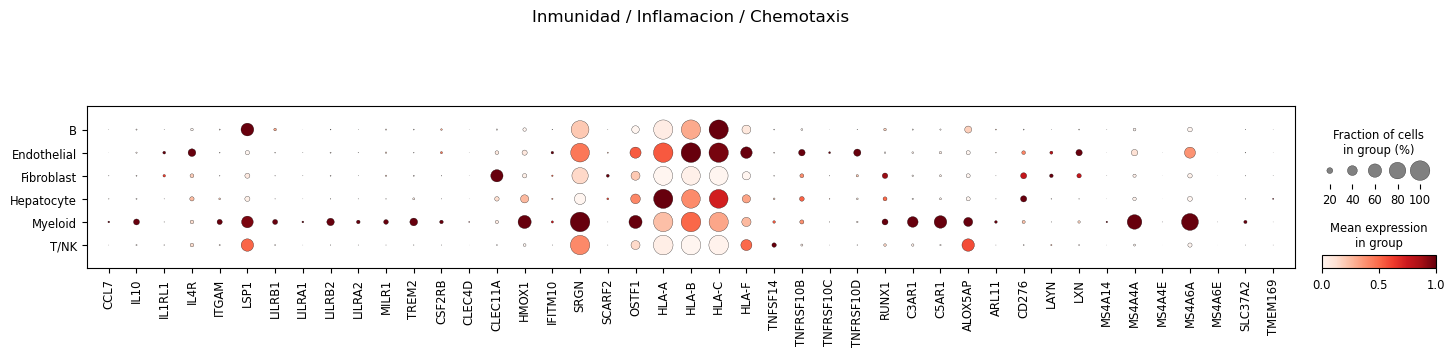

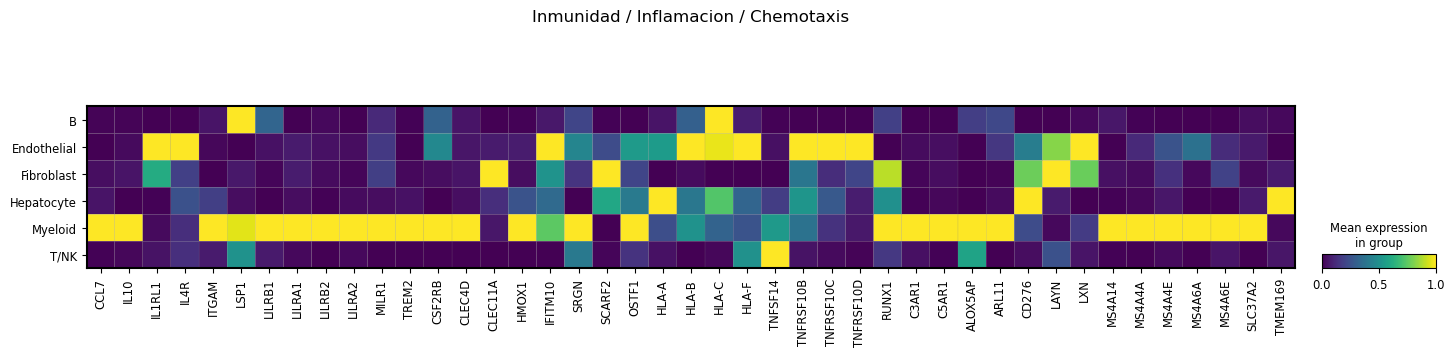

In [13]:
# ================================
# BLOQUE 2 · Analisis por grupo_general
# ================================

grupo = "Inmunidad / Inflamacion / Chemotaxis"
# otros ejemplos:
# grupo = "Inmunidad / Inflamacion / Chemotaxis"
# grupo = "Angiogenesis / Vascular / Hipoxia"
# grupo = "Señalizacion / Regulacion celular"
# grupo = "Otros / poco clara"

columna_grupo = "grupo_general"

# Sacar genes del grupo general
genes_grupo = (
    genes_df.loc[genes_df[columna_grupo] == grupo, gene_col]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"Grupo general: {grupo}")
print(f"Número total de genes en el grupo: {len(genes_grupo)}")
print("Primeros genes del grupo:", genes_grupo[:10])

# Comprobar cuáles están presentes en el dataset
genes_presentes_grupo = [g for g in genes_grupo if g in adata.var_names]

print(f"Número de genes presentes en el dataset: {len(genes_presentes_grupo)}")
print("Primeros genes presentes:", genes_presentes_grupo[:10])

# Limpiar nombre para guardar figuras
grupo_safe = (
    grupo.replace(" ", "_")
         .replace("/", "_")
         .replace("á", "a")
         .replace("é", "e")
         .replace("í", "i")
         .replace("ó", "o")
         .replace("ú", "u")
)

if len(genes_presentes_grupo) == 0:
    print("No hay genes de este grupo presentes en el dataset.")
else:
    sc.settings.figdir = FIGURES_DATASET_DIR

    # Dotplot
    sc.pl.dotplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_dotplot.png"
    )

    # Matrixplot
    sc.pl.matrixplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_matrixplot.png"
    )

# Señalizacion / Regulacion celular

Grupo general: Señalizacion / Regulacion celular
Número total de genes en el grupo: 31
Primeros genes del grupo: ['ADGRD1', 'ADRA2A', 'AGBL2', 'AHNAK2', 'BAALC', 'BHLHE22', 'CLDN10', 'CMTM3', 'DIO3', 'ECRG4']
Número de genes presentes en el dataset: 28
Primeros genes presentes: ['ADGRD1', 'ADRA2A', 'AGBL2', 'AHNAK2', 'BAALC', 'BHLHE22', 'CLDN10', 'CMTM3', 'DIO3', 'FKBP1B']


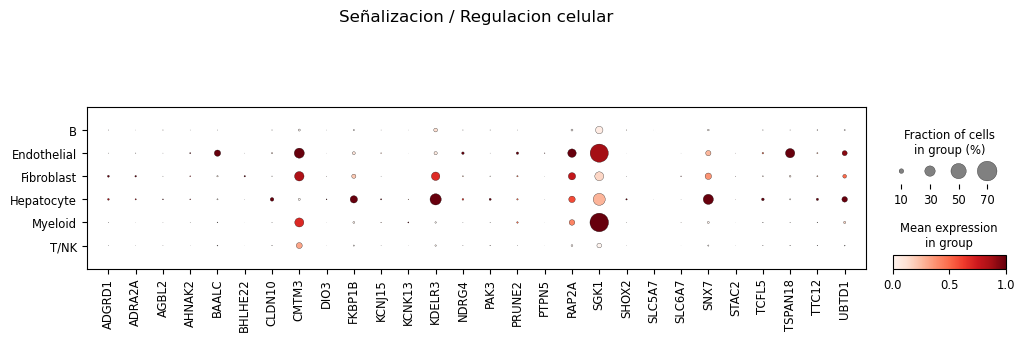

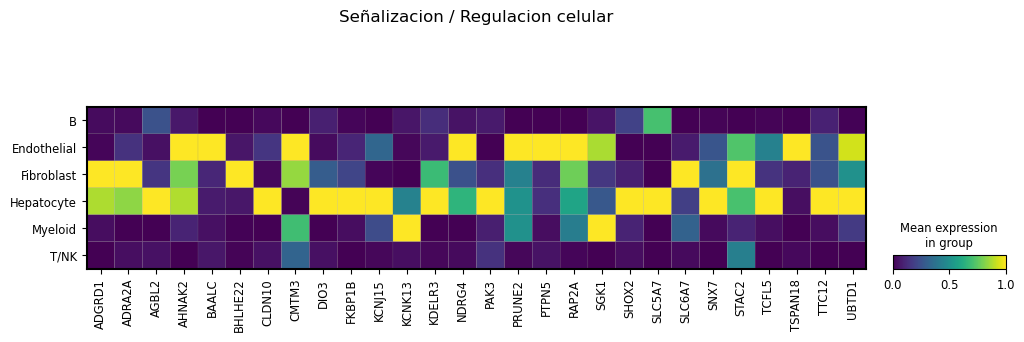

In [14]:
# ================================
# BLOQUE 2 · Analisis por grupo_general
# ================================

grupo = "Señalizacion / Regulacion celular"
# otros ejemplos:
# grupo = "Inmunidad / Inflamacion / Chemotaxis"
# grupo = "Angiogenesis / Vascular / Hipoxia"
# grupo = "Señalizacion / Regulacion celular"
# grupo = "Otros / poco clara"

columna_grupo = "grupo_general"

# Sacar genes del grupo general
genes_grupo = (
    genes_df.loc[genes_df[columna_grupo] == grupo, gene_col]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"Grupo general: {grupo}")
print(f"Número total de genes en el grupo: {len(genes_grupo)}")
print("Primeros genes del grupo:", genes_grupo[:10])

# Comprobar cuáles están presentes en el dataset
genes_presentes_grupo = [g for g in genes_grupo if g in adata.var_names]

print(f"Número de genes presentes en el dataset: {len(genes_presentes_grupo)}")
print("Primeros genes presentes:", genes_presentes_grupo[:10])

# Limpiar nombre para guardar figuras
grupo_safe = (
    grupo.replace(" ", "_")
         .replace("/", "_")
         .replace("á", "a")
         .replace("é", "e")
         .replace("í", "i")
         .replace("ó", "o")
         .replace("ú", "u")
)

if len(genes_presentes_grupo) == 0:
    print("No hay genes de este grupo presentes en el dataset.")
else:
    sc.settings.figdir = FIGURES_DATASET_DIR

    # Dotplot
    sc.pl.dotplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_dotplot.png"
    )

    # Matrixplot
    sc.pl.matrixplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_matrixplot.png"
    )

# Angiogenesis / Vascular / Hipoxia

Grupo general: Angiogenesis / Vascular / Hipoxia
Número total de genes en el grupo: 15
Primeros genes del grupo: ['ACVRL1', 'ANGPTL2', 'CCBE1', 'PDGFRL', 'ENPP1', 'WNT16', 'SLIT2', 'SLIT3', 'PLXNA4', 'SOD3']
Número de genes presentes en el dataset: 14
Primeros genes presentes: ['ACVRL1', 'ANGPTL2', 'CCBE1', 'PDGFRL', 'ENPP1', 'WNT16', 'SLIT2', 'SLIT3', 'PLXNA4', 'SOD3']


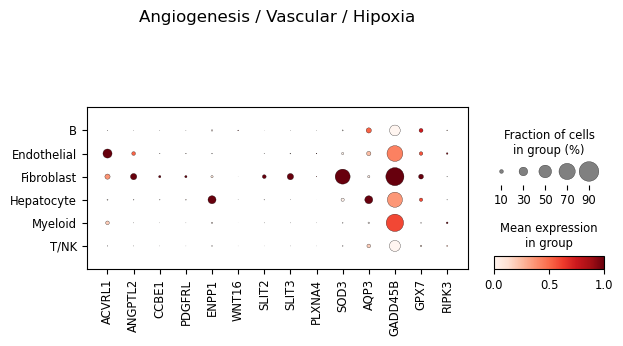

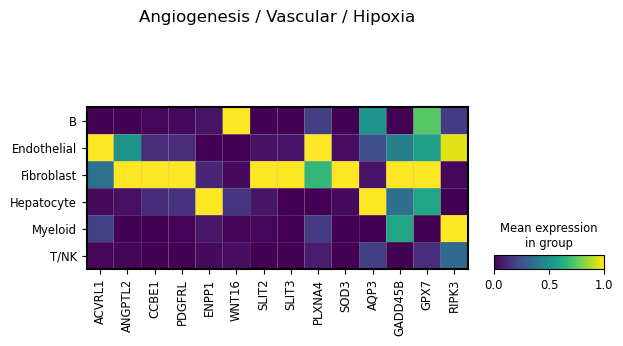

In [15]:
# ================================
# BLOQUE 2 · Analisis por grupo_general
# ================================

grupo = "Angiogenesis / Vascular / Hipoxia"
# otros ejemplos:
# grupo = "Inmunidad / Inflamacion / Chemotaxis"
# grupo = "Angiogenesis / Vascular / Hipoxia"
# grupo = "Señalizacion / Regulacion celular"
# grupo = "Otros / poco clara"

columna_grupo = "grupo_general"

# Sacar genes del grupo general
genes_grupo = (
    genes_df.loc[genes_df[columna_grupo] == grupo, gene_col]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"Grupo general: {grupo}")
print(f"Número total de genes en el grupo: {len(genes_grupo)}")
print("Primeros genes del grupo:", genes_grupo[:10])

# Comprobar cuáles están presentes en el dataset
genes_presentes_grupo = [g for g in genes_grupo if g in adata.var_names]

print(f"Número de genes presentes en el dataset: {len(genes_presentes_grupo)}")
print("Primeros genes presentes:", genes_presentes_grupo[:10])

# Limpiar nombre para guardar figuras
grupo_safe = (
    grupo.replace(" ", "_")
         .replace("/", "_")
         .replace("á", "a")
         .replace("é", "e")
         .replace("í", "i")
         .replace("ó", "o")
         .replace("ú", "u")
)

if len(genes_presentes_grupo) == 0:
    print("No hay genes de este grupo presentes en el dataset.")
else:
    sc.settings.figdir = FIGURES_DATASET_DIR

    # Dotplot
    sc.pl.dotplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_dotplot.png"
    )

    # Matrixplot
    sc.pl.matrixplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_matrixplot.png"
    )

# Otros / poco clara

Grupo general: Otros / poco clara
Número total de genes en el grupo: 16
Primeros genes del grupo: ['ARSJ', 'CHODL', 'CLIP3', 'EEF1AKMT3', 'F2RL2', 'FKBP14', 'GPR153', 'GRIA3', 'M1AP', 'NSG1']
Número de genes presentes en el dataset: 15
Primeros genes presentes: ['ARSJ', 'CHODL', 'CLIP3', 'F2RL2', 'FKBP14', 'GPR153', 'GRIA3', 'M1AP', 'NSG1', 'PLEKHG4']


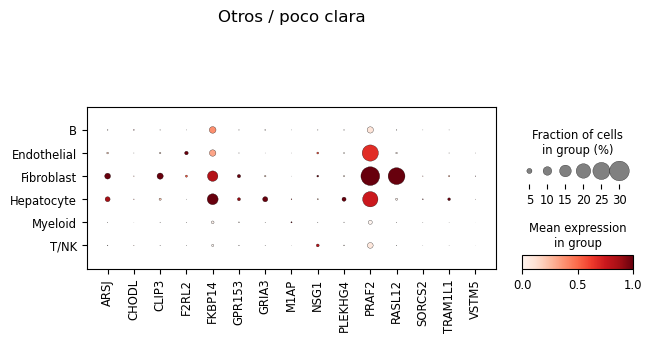

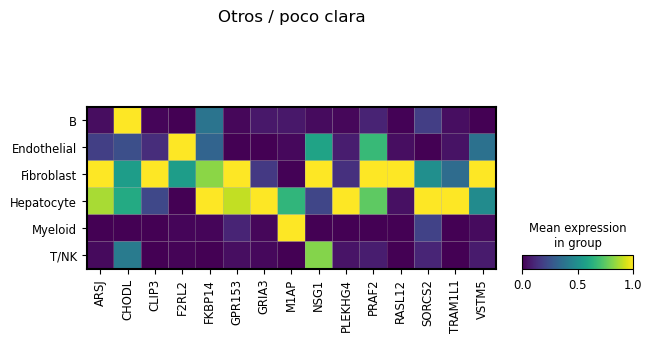

In [16]:
# ================================
# BLOQUE 2 · Analisis por grupo_general
# ================================

grupo = "Otros / poco clara"
# otros ejemplos:
# grupo = "Inmunidad / Inflamacion / Chemotaxis"
# grupo = "Angiogenesis / Vascular / Hipoxia"
# grupo = "Señalizacion / Regulacion celular"
# grupo = "Otros / poco clara"

columna_grupo = "grupo_general"

# Sacar genes del grupo general
genes_grupo = (
    genes_df.loc[genes_df[columna_grupo] == grupo, gene_col]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"Grupo general: {grupo}")
print(f"Número total de genes en el grupo: {len(genes_grupo)}")
print("Primeros genes del grupo:", genes_grupo[:10])

# Comprobar cuáles están presentes en el dataset
genes_presentes_grupo = [g for g in genes_grupo if g in adata.var_names]

print(f"Número de genes presentes en el dataset: {len(genes_presentes_grupo)}")
print("Primeros genes presentes:", genes_presentes_grupo[:10])

# Limpiar nombre para guardar figuras
grupo_safe = (
    grupo.replace(" ", "_")
         .replace("/", "_")
         .replace("á", "a")
         .replace("é", "e")
         .replace("í", "i")
         .replace("ó", "o")
         .replace("ú", "u")
)

if len(genes_presentes_grupo) == 0:
    print("No hay genes de este grupo presentes en el dataset.")
else:
    sc.settings.figdir = FIGURES_DATASET_DIR

    # Dotplot
    sc.pl.dotplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_dotplot.png"
    )

    # Matrixplot
    sc.pl.matrixplot(
        adata,
        var_names=genes_presentes_grupo,
        groupby="celltype",
        standard_scale="var",
        title=grupo,
        save=f"_{grupo_safe}_matrixplot.png"
    )

In [17]:
# ver que columnas tengo
print(adata.obs.columns.tolist())

['sample', 'res.3', 'site', 'patient', 'stage', 'virus', 'celltype']


In [18]:
# Tabla clusters
cluster_counts = adata.obs['res.3'].value_counts().sort_index()
cluster_percent = (cluster_counts / cluster_counts.sum()) * 100

import pandas as pd

tabla_clusters = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "N_celulas": cluster_counts.values,
    "Porcentaje": cluster_percent.values
})

tabla_clusters["Tipo_celular"] = adata.obs.groupby("res.3")["celltype"].first().values
tabla_clusters

,Cluster,N_celulas,Porcentaje,Tipo_celular
0,1,3742,5.203437,T/NK
1,2,3305,4.595767,T/NK
2,3,3131,4.353811,Hepatocyte
3,4,3064,4.260645,Hepatocyte
4,5,2467,3.430486,Myeloid
5,6,2197,3.055038,Myeloid
6,7,2175,3.024446,Endothelial
7,8,2139,2.974386,T/NK
8,9,2120,2.947966,T/NK
9,10,2060,2.864533,Myeloid


In [25]:
# Tabla resumida x tipo cel
tabla_celltypes = adata.obs['celltype'].value_counts().reset_index()
tabla_celltypes.columns = ["Tipo_celular", "N_celulas"]

tabla_celltypes["Porcentaje"] = (tabla_celltypes["N_celulas"] / tabla_celltypes["N_celulas"].sum()) * 100

# Añadir fila TOTAL
total_row = pd.DataFrame({
    "Tipo_celular": ["TOTAL"],
    "N_celulas": [tabla_celltypes["N_celulas"].sum()],
    "Porcentaje": [100]
})

tabla_celltypes = pd.concat([tabla_celltypes, total_row], ignore_index=True)


# Guardarla
tabla_celltypes.to_excel(os.path.join(RESULTS_DIR, "tabla_celltypes_GSE149614.xlsx"), index=False)

print(tabla_celltypes)

  Tipo_celular  N_celulas  Porcentaje
0         T/NK      25590   35.584170
1   Hepatocyte      20782   28.898406
2      Myeloid      15947   22.175098
3            B       3685    5.124176
4  Endothelial       3644    5.067164
5   Fibroblast       2266    3.150986
6        TOTAL      71914  100.000000


In [20]:
# PCA y vecinos para UMAP
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata_umap = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata_umap, max_value=10)
sc.tl.pca(adata_umap, svd_solver='arpack')
sc.pp.neighbors(adata_umap, n_neighbors=10, n_pcs=20)
sc.tl.umap(adata_umap)

/home/iruizdealda/.conda/envs/hcc_scanpy_clean/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/iruizdealda/.conda/envs/hcc_scanpy_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


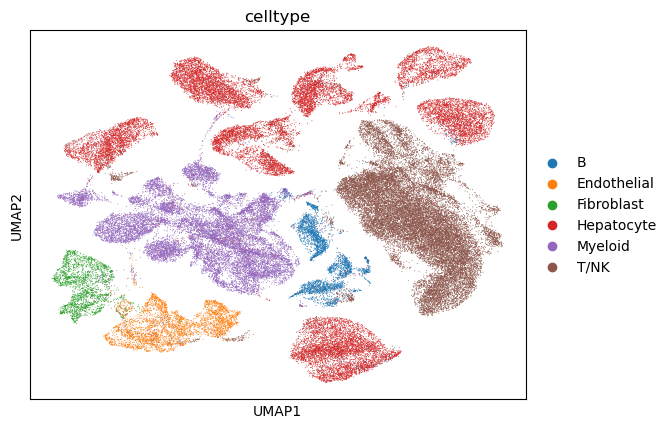

In [ ]:
# Guardar UMAP
sc.pl.umap(adata_umap, color=['celltype'], save="umap_celltypes.png")